In [1]:
# ============================================================
# CAPSTONE PROJECT: Student Exam Score Prediction
# PG Certificate in Applied Data Science & AI
# E&ICT Academy IIT Roorkee — 2025
#
# Dataset : Student Performance and Learning Behavior Dataset
# Source  : https://www.kaggle.com/datasets/adilshamim8/student-performance-and-learning-style
#
# Models  : Linear Regression | Ridge | Random Forest | Extra Trees | XGBoost
#
# Metrics : Cross-Validated MAE | Cross-Validated RMSE | Cross-Validated R² Score
# CV      : 10-Fold Cross Validation
# Tuning  : GridSearchCV (scoring = neg_mean_squared_error)
# ============================================================

In [2]:
# ─────────────────────────────────────────────────────────────
# SECTION 0 – Environment Setup & Imports
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Scikit-learn — model selection & preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scikit-learn — regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# XGBoost
from xgboost import XGBRegressor

# ── Global config ───────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 130, "font.family": "DejaVu Sans"})
RANDOM_STATE = 42
CV_FOLDS = 10      # 10-fold cross validation throughout
np.random.seed(RANDOM_STATE)

# ── Output directories ─────────────────────────────────────
os.makedirs("plots", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("[OK] All imports successful.")
print(f"[OK] CV folds           : {CV_FOLDS}")

[OK] All imports successful.
[OK] CV folds           : 10


In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 – Load Dataset
# ─────────────────────────────────────────────────────────────

CSV_PATH = "data/student_performance.csv"

try:
    df = pd.read_csv(CSV_PATH)
    print(f"[OK] Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
except FileNotFoundError:
    raise FileNotFoundError(
        f"\n[ERROR] Cannot find '{CSV_PATH}'.\n"
        "Download the dataset from Kaggle and place it in data/student_performance.csv"
    )

[OK] Dataset loaded: 14003 rows × 16 columns


In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 – Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 2 – Exploratory Data Analysis")
print("="*60)

TARGET = "ExamScore"

print("\n--- Shape & Column Types ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Descriptive Statistics ---")
print(df.describe(include="all").T)

print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

print("\n--- Duplicate Rows ---")
print(f"Duplicates: {df.duplicated().sum()}")

print(f"\n--- Target Variable ({TARGET}) Distribution ---")
print(df[TARGET].describe())
print(f"Skewness : {df[TARGET].skew():.4f}")



SECTION 2 – Exploratory Data Analysis

--- Shape & Column Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-n

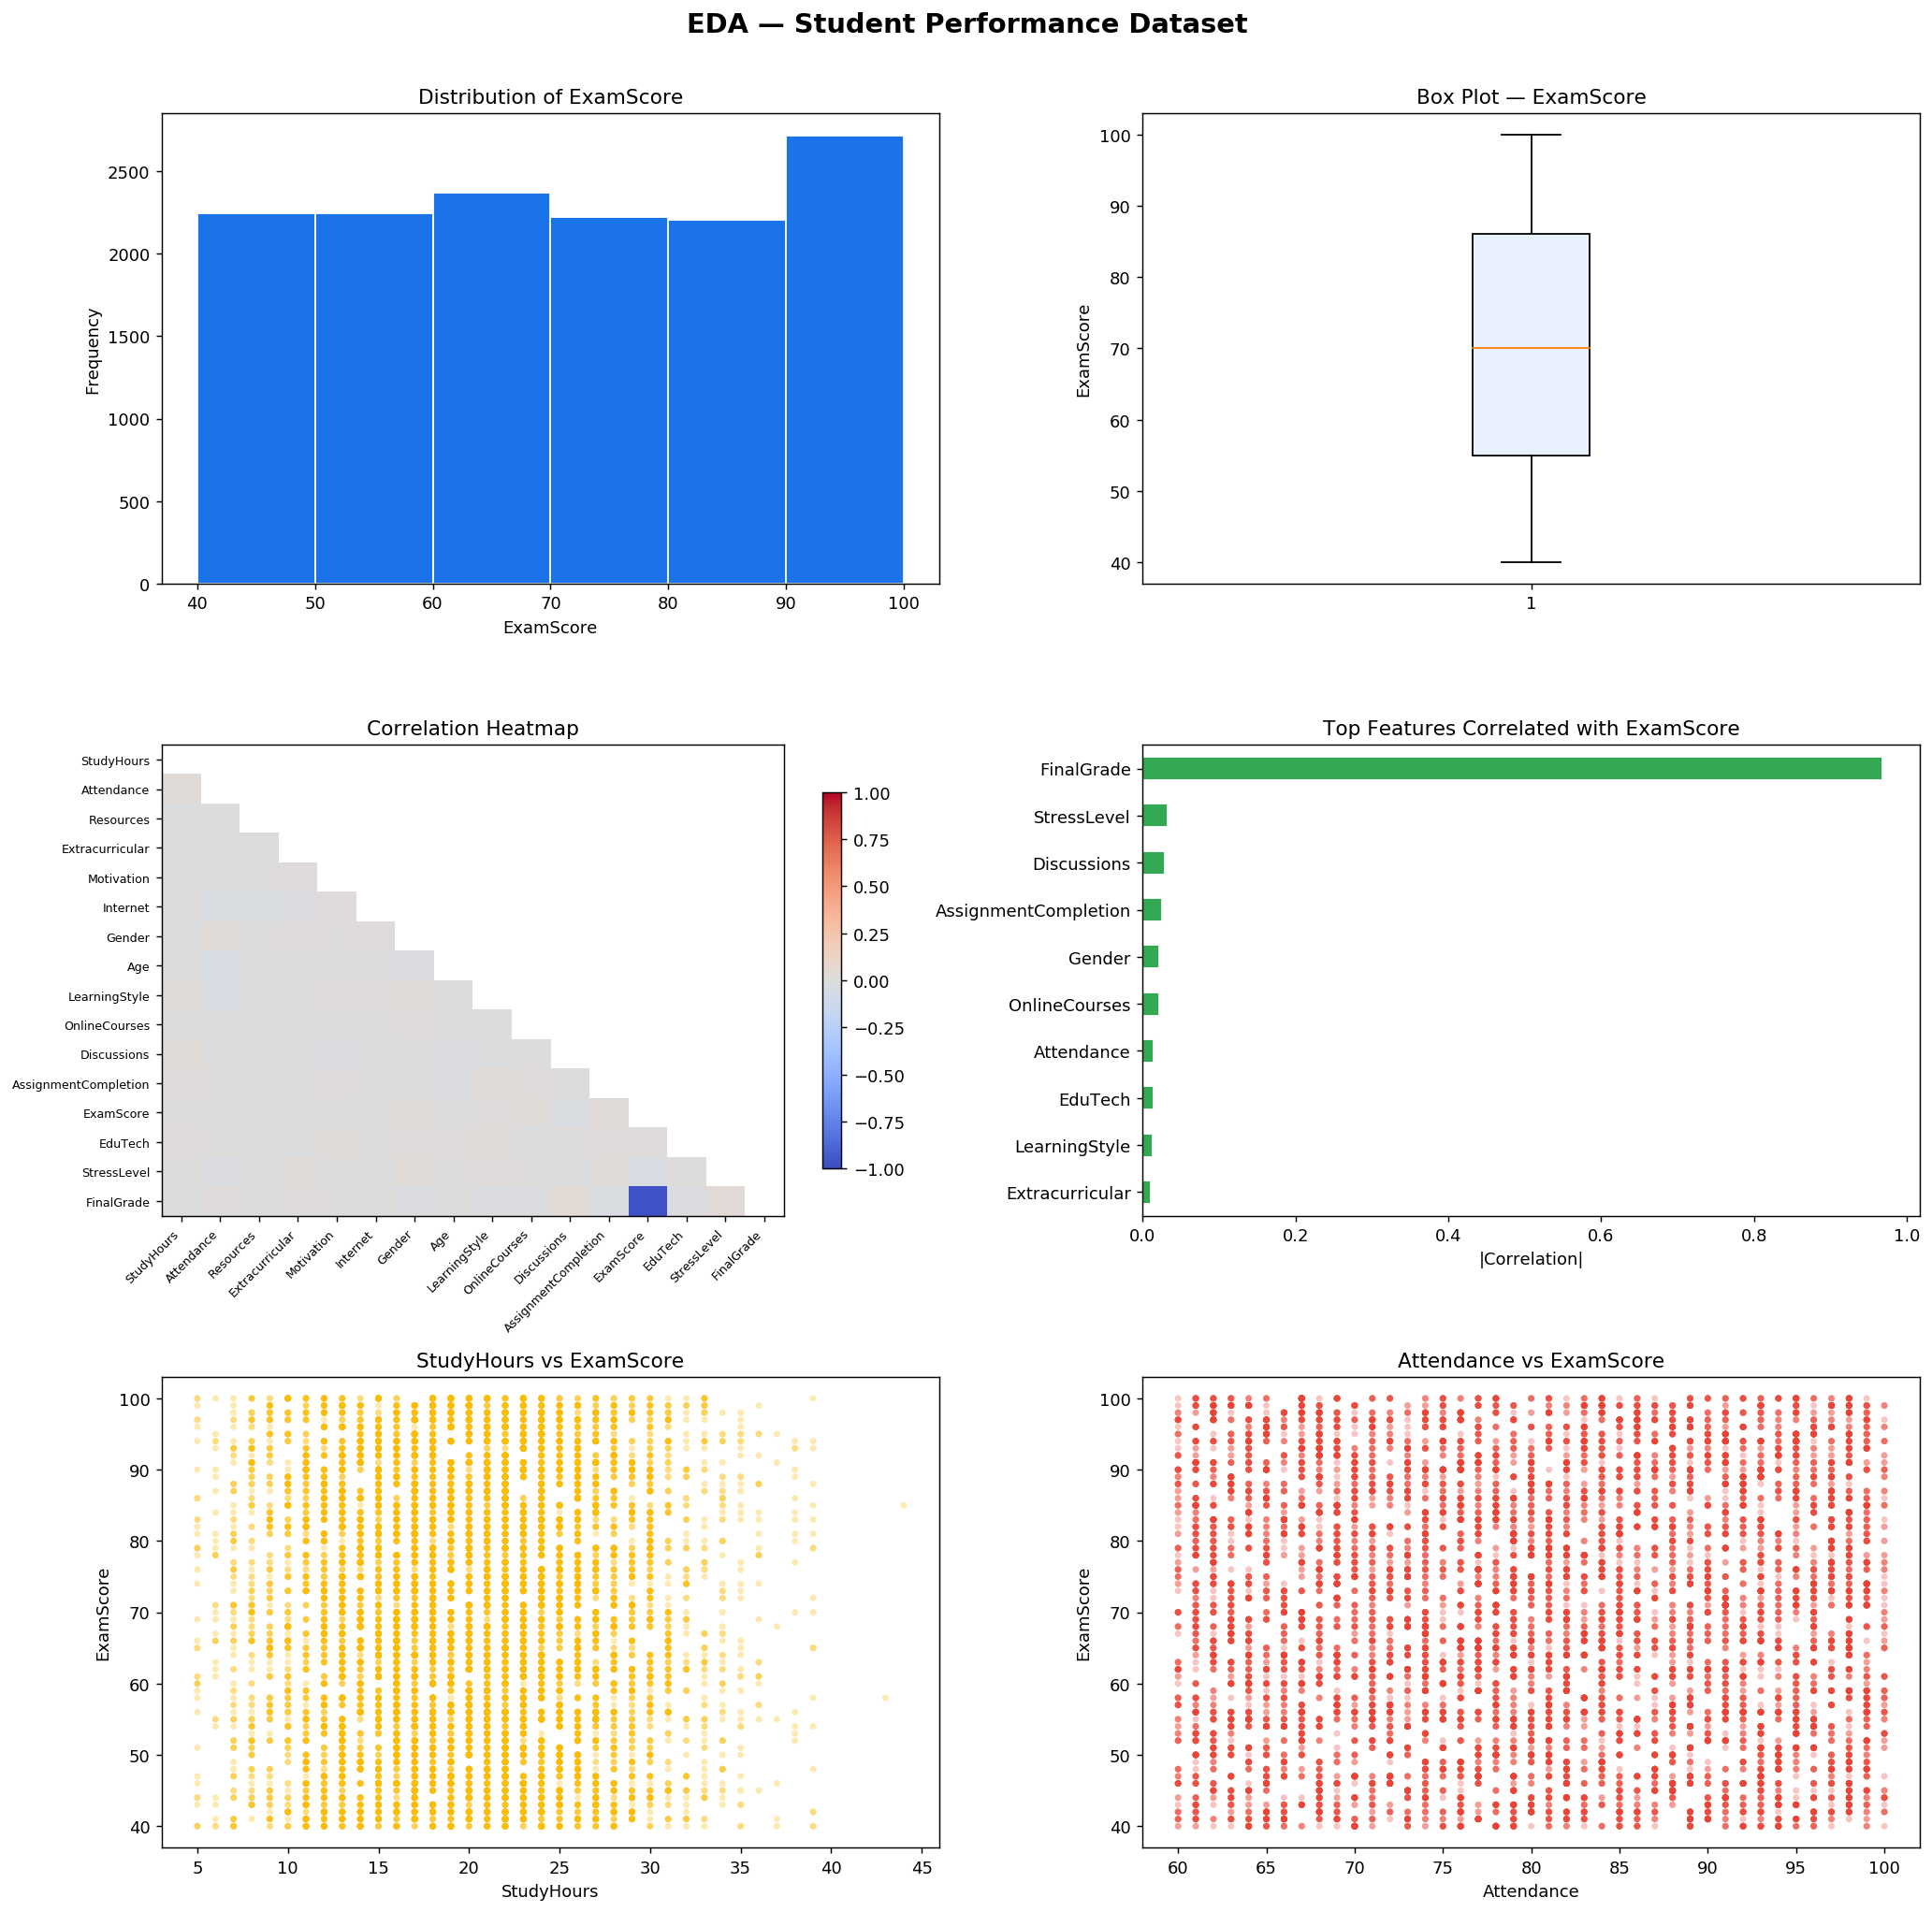

[OK] EDA plot saved → plots/eda_overview.png


In [5]:
# ─────────────────────────────────────────────────────────────
# EDA Plots
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle("EDA — Student Performance Dataset", fontsize=16, fontweight="bold")

# 1. Target distribution
axes[0, 0].hist(df[TARGET].dropna(), bins=6, color="#1A73E8", edgecolor="white")
axes[0, 0].set_title(f"Distribution of {TARGET}")
axes[0, 0].set_xlabel(TARGET)
axes[0, 0].set_ylabel("Frequency")

# 2. Box plot of target
axes[0, 1].boxplot(df[TARGET].dropna(), patch_artist=True, boxprops=dict(facecolor="#E8F0FE"))
axes[0, 1].set_title(f"Box Plot — {TARGET}")
axes[0, 1].set_ylabel(TARGET)

# 3. Correlation heatmap (no seaborn)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.where(~mask)
im = axes[1, 0].imshow(corr_masked.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
axes[1, 0].set_xticks(range(len(corr.columns)))
axes[1, 0].set_yticks(range(len(corr.columns)))
axes[1, 0].set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
axes[1, 0].set_yticklabels(corr.columns, fontsize=7)
if len(numeric_cols) <= 12:
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr_masked.values[i, j]
            if not np.isnan(val):
                axes[1, 0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=5.5)
plt.colorbar(im, ax=axes[1, 0], shrink=0.8)
axes[1, 0].set_title("Correlation Heatmap")

# 4. Top feature correlations with target
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=True)
target_corr.tail(min(10, len(target_corr))).plot(kind="barh", ax=axes[1, 1], color="#34A853", edgecolor="white")
axes[1, 1].set_title(f"Top Features Correlated with {TARGET}")
axes[1, 1].set_xlabel("|Correlation|")

# 5. StudyHours vs Target
study_col = next((c for c in df.columns if "study" in c.lower()), None)
if study_col:
    axes[2, 0].scatter(df[study_col], df[TARGET], alpha=0.3, color="#FBBC04", edgecolor="none", s=15)
    axes[2, 0].set_xlabel(study_col)
    axes[2, 0].set_ylabel(TARGET)
    axes[2, 0].set_title(f"{study_col} vs {TARGET}")
else:
    axes[2, 0].text(0.5, 0.5, "StudyHours not found", ha="center", va="center", transform=axes[2, 0].transAxes)

# 6. Attendance vs Target
att_col = next((c for c in df.columns if "attend" in c.lower()), None)
if att_col:
    axes[2, 1].scatter(df[att_col], df[TARGET], alpha=0.3, color="#EA4335", edgecolor="none", s=15)
    axes[2, 1].set_xlabel(att_col)
    axes[2, 1].set_ylabel(TARGET)
    axes[2, 1].set_title(f"{att_col} vs {TARGET}")
else:
    axes[2, 1].text(0.5, 0.5, "Attendance not found", ha="center", va="center", transform=axes[2, 1].transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("plots/eda_overview.png", bbox_inches="tight")
plt.show()
print("[OK] EDA plot saved → plots/eda_overview.png")

In [6]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 – Initial Data Cleaning & Train/Test Split
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 3 – Initial Data Cleaning & Train/Test Split")
print("="*60)

df_clean = df.copy()

# 3.1 Remove data-leakage column
# FinalGrade is derived from ExamScore after the exam — including it would leak post-exam information into the model 
# (correlation ≈ 1.0).
if "FinalGrade" in df_clean.columns:
    df_clean.drop(columns=["FinalGrade"], inplace=True)
    print("[OK] Removed leakage column: FinalGrade")

# 3.2 Drop exact duplicate rows
before_dup = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"[OK] Duplicates removed : {before_dup - len(df_clean)}")

# 3.3 Feature / target split
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]
print(f"[OK] Features : {X.shape[1]} | Samples : {len(y)}")

# 3.4 Train / Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"[OK] Train : {X_train.shape} | Test : {X_test.shape}")


SECTION 3 – Initial Data Cleaning & Train/Test Split
[OK] Removed leakage column: FinalGrade
[OK] Duplicates removed : 1534
[OK] Features : 14 | Samples : 12469
[OK] Train : (9975, 14) | Test : (2494, 14)


In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 – Data Preprocessing on Training Data
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 4 – Data Preprocessing on Training Data")
print("="*60)

# 4.1 Handle missing values
for col in X_train.columns:
    if X_train[col].dtype in [np.float64, np.int64]:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)
    else:
        mode_val = X_train[col].mode()[0]
        X_train[col].fillna(mode_val, inplace=True)
        X_test[col].fillna(mode_val, inplace=True)
print(f"[OK] Missing after imputation in datasets")
print(f"Training dataset : {X_train.isnull().sum().sum()}")
print(f"Testing dataset : {X_test.isnull().sum().sum()}")

# 4.2 Outlier removal on training target only
Q1, Q3 = y_train.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
before_out = len(y_train)
mask = (y_train >= lower) & (y_train <= upper)
X_train = X_train[mask]
y_train = y_train[mask]
print(f"[OK] Outliers removed : {before_out - len(y_train)} rows | Remaining: {len(y_train)}")

# 4.3 Feature scaling — only for linear models
# Tree-based models (RF, Extra Trees, XGBoost) do not require scaling.
# Fit scaler only on training data to avoid data leakage.
scaler = StandardScaler()
# Keep original (unscaled) data for tree models
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()
# Create scaled versions for linear models
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"[OK] Train (Scaled)   : {X_train_scaled.shape}")
print(f"[OK] Test (Scaled)    : {X_test_scaled.shape}")
print(f"[OK] Train (Unscaled) : {X_train_unscaled.shape}")
print(f"[OK] Test (Unscaled)  : {X_test_unscaled.shape}")


SECTION 4 – Data Preprocessing on Training Data
[OK] Missing after imputation in datasets
Training dataset : 0
Testing dataset : 0
[OK] Outliers removed : 0 rows | Remaining: 9975
[OK] Train (Scaled)   : (9975, 14)
[OK] Test (Scaled)    : (2494, 14)
[OK] Train (Unscaled) : (9975, 14)
[OK] Test (Unscaled)  : (2494, 14)



SECTION 5 – Feature Importance Analysis

--- Top Features (Random Forest Importance) ---
              Feature  Importance
           Attendance    0.179288
 AssignmentCompletion    0.174952
           StudyHours    0.164359
        OnlineCourses    0.149075
                  Age    0.115289
        LearningStyle    0.064353
          StressLevel    0.038425
               Gender    0.030682
              EduTech    0.027024
          Discussions    0.025780
           Motivation    0.010678
            Resources    0.010240
      Extracurricular    0.005567
             Internet    0.004288


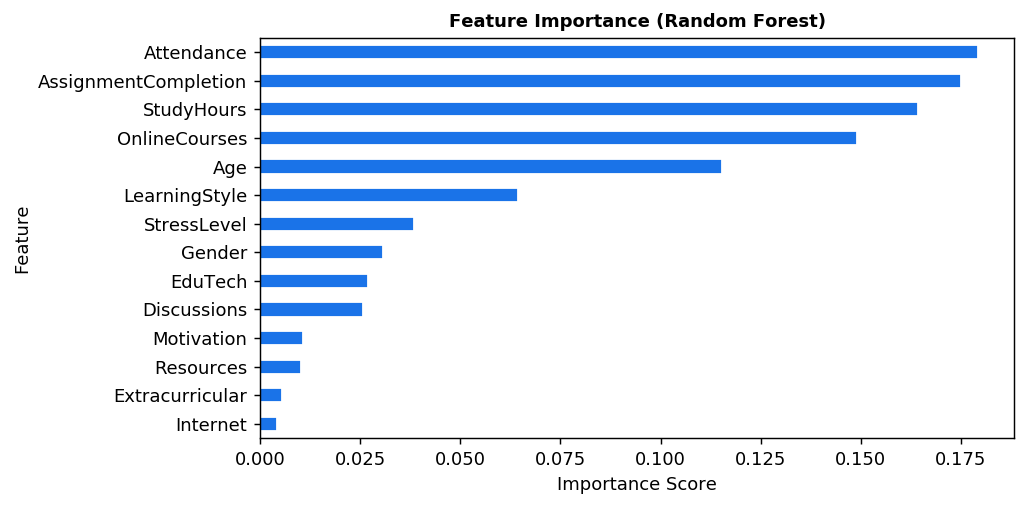

[OK] Feature importance plot saved → plots/feature_importance.png


In [8]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 – Feature Importance Analysis
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 5 – Feature Importance Analysis")
print("="*60)

# Use a Random Forest to compute feature importances
_rf_fi = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
_rf_fi.fit(X_train_unscaled, y_train)

fi_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": _rf_fi.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("\n--- Top Features (Random Forest Importance) ---")
print(fi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
top_n = min(15, len(fi_df))
fi_df.head(top_n).sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance",
    ax=ax, color="#1A73E8", legend=False, edgecolor="white"
)
ax.set_title("Feature Importance (Random Forest)", fontsize=10, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plots/feature_importance.png", bbox_inches="tight")
plt.show()
print("[OK] Feature importance plot saved → plots/feature_importance.png")

In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 – Model Training
# ─────────────────────────────────────────────────────────────
# Pipeline:
#   5a  All ML models — trained + 10-fold CV (MAE, RMSE & R²)
#   5b  Model comparison leaderboard & plots
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 6 – Model Training & 10-Fold Cross Validation")
print("="*60)

# ── 5a. ML Models — 10-Fold Cross Validation ─────────────────────────
# Using cross_val_score() with:
#   scoring="neg_mean_absolute_error"  → CV MAE  = -scores.mean()
#   scoring="neg_mean_squared_error"   → CV RMSE = sqrt(-mse_scores.mean())
#   scoring="r2"                       → CV R2   = r2_scores.mean()
# All models use 10-fold CV on the training set for fair comparison.

# ── Define all ML models ───────────────────────────────────────────────
ml_models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees"        : ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost"            : XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE, verbosity=0)
}

# ── Run 10-fold CV for each model ─────────────────────────────────────
print(f"\nRunning {CV_FOLDS}-Fold Cross Validation on all models...\n")
print(f"{'Model':<22} {'CV MAE':>10} {'CV RMSE':>10} {'CV R2':>10}")
print("-" * 55)

cv_results = []

for name, model in ml_models.items():
    # Use scaled data only for linear models
    if name in ["Linear Regression", "Ridge Regression"]:
        X_cv = X_train_scaled
    else:
        X_cv = X_train_unscaled
      
    # CV MAE
    mae_scores = cross_val_score(model, X_cv, y_train, cv=CV_FOLDS, scoring="neg_mean_absolute_error")
    cv_mae = -mae_scores.mean()

    # CV RMSE
    mse_scores = cross_val_score(model, X_cv, y_train, cv=CV_FOLDS, scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-mse_scores.mean())

    # CV R²
    r2_scores = cross_val_score(model, X_cv, y_train, cv=CV_FOLDS, scoring="r2")
    cv_r2 = r2_scores.mean()

    cv_results.append({
        "Model"  : name,
        "CV MAE" : round(cv_mae,  4),
        "CV RMSE": round(cv_rmse, 4),
        "CV R2"  : round(cv_r2,   4),
    })
    print(f"{name:<22} {cv_mae:>10.4f} {cv_rmse:>10.4f} {cv_r2:>10.4f}")

# ── Build CV leaderboard ───────────────────────────────────────────────
cv_df = (pd.DataFrame(cv_results).sort_values("CV RMSE", ascending=True).reset_index(drop=True))

print("\n--- 10-Fold CV Leaderboard ---")
print(cv_df.to_string(index=False))

# ── Identify best model for hyperparameter tuning ─────────────────────
best_name  = cv_df.iloc[0]["Model"]
best_model = ml_models[best_name]
print(f"\n  Best Model (lowest CV RMSE): {best_name}")
print(f"   CV MAE  = {cv_df.iloc[0]['CV MAE']:.4f}")
print(f"   CV RMSE = {cv_df.iloc[0]['CV RMSE']:.4f}")
print(f"   CV R2   = {cv_df.iloc[0]['CV R2']:.4f}")


SECTION 6 – Model Training & 10-Fold Cross Validation

Running 10-Fold Cross Validation on all models...

Model                      CV MAE    CV RMSE      CV R2
-------------------------------------------------------
Linear Regression         15.3192    17.6833    -0.0015
Ridge Regression          15.3192    17.6833    -0.0015
Random Forest              5.5045     8.5878     0.7637
Extra Trees                4.9982     8.3140     0.7784
XGBoost                    9.4424    12.0474     0.5350

--- 10-Fold CV Leaderboard ---
             Model   CV MAE  CV RMSE   CV R2
       Extra Trees   4.9982   8.3140  0.7784
     Random Forest   5.5045   8.5878  0.7637
           XGBoost   9.4424  12.0474  0.5350
 Linear Regression  15.3192  17.6833 -0.0015
  Ridge Regression  15.3192  17.6833 -0.0015

  Best Model (lowest CV RMSE): Extra Trees
   CV MAE  = 4.9982
   CV RMSE = 8.3140
   CV R2   = 0.7784


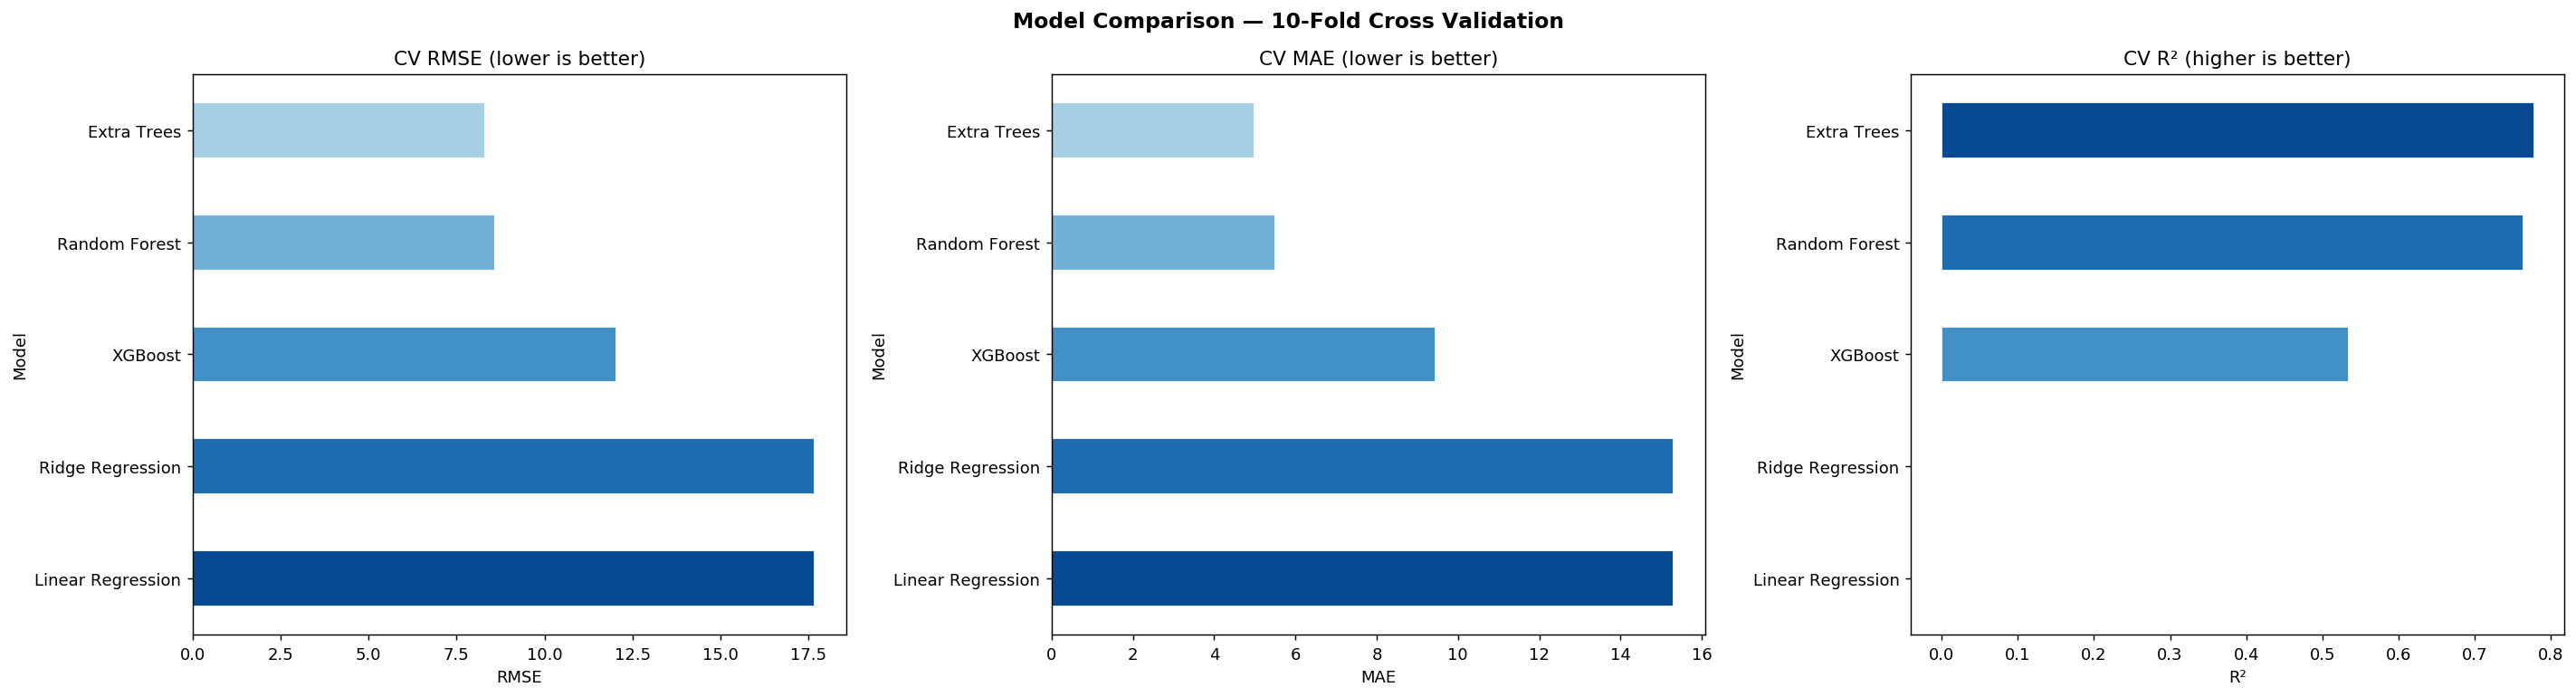

[OK] Model comparison (CV) plot saved → plots/model_comparison_cv.png


In [10]:
# ── 5b. Model Comparison Plots (CV Metrics) ───────────────────────────

display_df = cv_df.copy()
display_df = display_df.sort_values("CV RMSE", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(f"Model Comparison — {CV_FOLDS}-Fold Cross Validation", fontsize=13, fontweight="bold")

colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(display_df)))

# RMSE bar chart
display_df.sort_values("CV RMSE", ascending=False).plot(
    kind="barh", x="Model", y="CV RMSE", ax=axes[0],
    color=colors[::-1], legend=False, edgecolor="white"
)
axes[0].set_title("CV RMSE (lower is better)")
axes[0].set_xlabel("RMSE")

# MAE bar chart
display_df.sort_values("CV MAE", ascending=False).plot(
    kind="barh", x="Model", y="CV MAE", ax=axes[1],
    color=colors[::-1], legend=False, edgecolor="white"
)
axes[1].set_title("CV MAE (lower is better)")
axes[1].set_xlabel("MAE")

# R² bar chart
display_df.sort_values("CV R2", ascending=True).plot(
    kind="barh", x="Model", y="CV R2", ax=axes[2],
    color=colors, legend=False, edgecolor="white"
)
axes[2].set_title("CV R² (higher is better)")
axes[2].set_xlabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("plots/model_comparison_cv.png", bbox_inches="tight")
plt.show()
print("[OK] Model comparison (CV) plot saved → plots/model_comparison_cv.png")

In [11]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 – Hyperparameter Tuning (GridSearchCV)
# ─────────────────────────────────────────────────────────────
# Tune the best model identified by 10-fold CV (model determined dynamically)
# scoring='neg_mean_squared_error' aligns with RMSE optimisation.
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print(f"SECTION 7 – Hyperparameter Tuning: Extra Trees")
print("="*60)

# ── Define parameter grid for Extra Trees ──
param_grid = {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20], "min_samples_split": [2, 5],}
base_estimator = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)


# ── GridSearchCV with neg_mean_squared_error ──────────────────────────
grid_search = GridSearchCV(
    estimator  = base_estimator,
    param_grid = param_grid,
    cv         = 5,
    scoring    = "neg_mean_squared_error",   # Optimise for RMSE
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train_unscaled, y_train)
tuned_model = grid_search.best_estimator_

print(f"\n[OK] Best hyperparameters : {grid_search.best_params_}")
print(f"[OK] Best CV neg-MSE      : {grid_search.best_score_:.4f}")

# ── Final test-set evaluation of tuned model ──────────────────────────
y_pred_final = tuned_model.predict(X_test_unscaled)
rmse_final   = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final    = mean_absolute_error(y_test, y_pred_final)
r2_final     = r2_score(y_test, y_pred_final)

print(f"\n--- Tuned {best_name} — Test-Set Performance ---")
print(f"  RMSE : {rmse_final:.4f}")
print(f"  MAE  : {mae_final:.4f}")
print(f"  R2   : {r2_final:.4f}")


SECTION 7 – Hyperparameter Tuning: Extra Trees
Fitting 5 folds for each of 18 candidates, totalling 90 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:  2.4min finished



[OK] Best hyperparameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
[OK] Best CV neg-MSE      : -82.7225

--- Tuned Extra Trees — Test-Set Performance ---
  RMSE : 7.3415
  MAE  : 4.1013
  R2   : 0.8289



--- Top Features (Extra Trees Importance) ---
              Feature  Importance
 AssignmentCompletion    0.150373
           Attendance    0.146455
        OnlineCourses    0.144791
           StudyHours    0.133299
                  Age    0.132682
        LearningStyle    0.089404
          StressLevel    0.050333
              EduTech    0.046440
               Gender    0.038407
          Discussions    0.017674
            Resources    0.015606
           Motivation    0.015583
      Extracurricular    0.011259
             Internet    0.007694


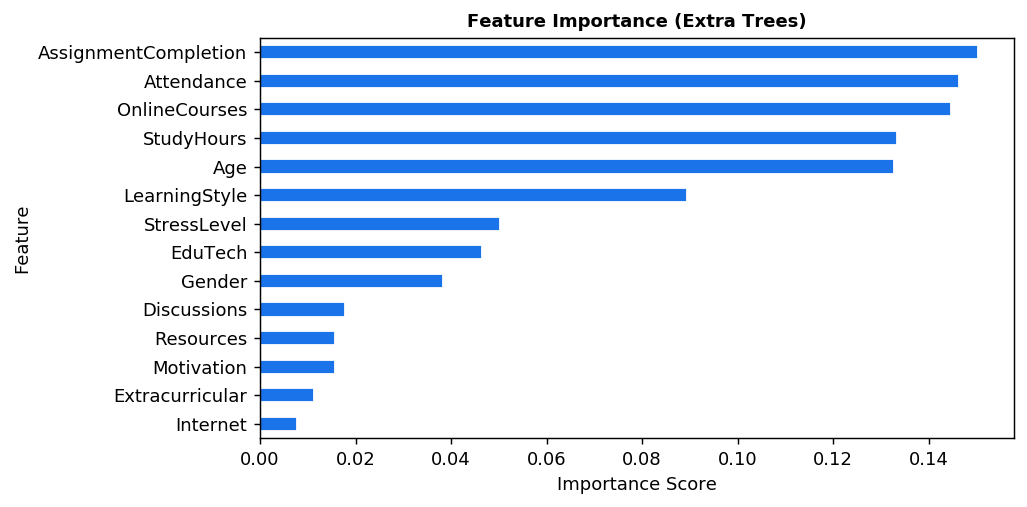

In [12]:
# ─────────────────────────────────────────────────────────────
# Feature Importance of Best Model
# ─────────────────────────────────────────────────────────────

final_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": tuned_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("\n--- Top Features (Extra Trees Importance) ---")
print(final_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
top_n = min(15, len(final_df))
final_df.head(top_n).sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance",
    ax=ax, color="#1A73E8", legend=False, edgecolor="white"
)
ax.set_title("Feature Importance (Extra Trees)", fontsize=10, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()


SECTION 8 – Results & Visualisation


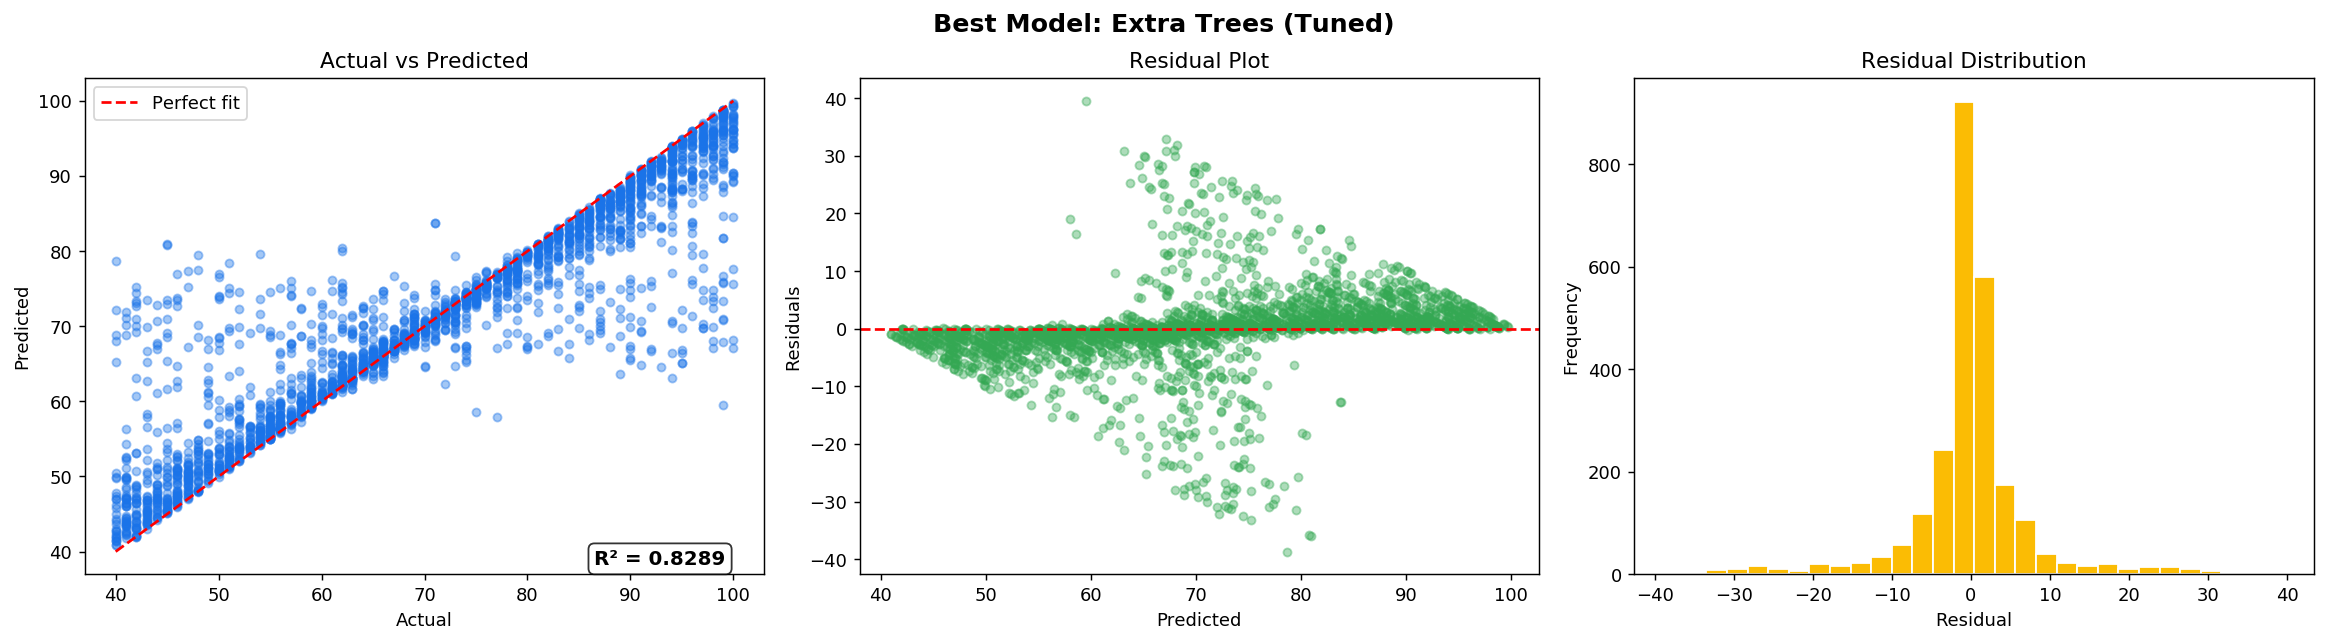

[OK] Final model diagnostics saved → plots/final_model_results.png


In [13]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 – Results & Visualisation
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 8 – Results & Visualisation")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Best Model: {best_name} (Tuned)", fontsize=14, fontweight="bold")

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_final, alpha=0.4, color="#1A73E8", s=20)
lims = [min(y_test.min(), y_pred_final.min()),
        max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
axes[0].text(0.75, 0.05, f"R² = {r2_final:.4f}", transform=axes[0].transAxes,
             fontsize=11, fontweight="bold", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 2. Residual Plot
residuals = y_test.values - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.4, color="#34A853", s=20)
axes[1].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

# 3. Residual Distribution
axes[2].hist(residuals, bins=30, color="#FBBC04", edgecolor="white")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Residual Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("plots/final_model_results.png", bbox_inches="tight")
plt.show()
print("[OK] Final model diagnostics saved → plots/final_model_results.png")

In [14]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 – Final Model Summary (10-Fold CV MAE | CV RMSE)
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 9 – Final Model Comparison (Cross-Validated)")
print("="*60)

# Replace base model row with tuned model metrics
summary = []
tuned_label = f"{best_name} (Tuned)"

for _, row in cv_df.iterrows():
    if row["Model"] == best_name:
        # Use tuned model's test-set scores for the final row
        summary.append({
            "Model"  : tuned_label,
            "CV MAE" : round(mae_final,  4),
            "CV RMSE": round(rmse_final, 4),
            "CV R2"  : round(r2_final,   4),
            "Note"   : "Tuned via GridSearchCV"
        })
    else:
        summary.append({
            "Model"  : row["Model"],
            "CV MAE" : row["CV MAE"],
            "CV RMSE": row["CV RMSE"],
            "CV R2"  : row["CV R2"],
            "Note"   : f"{CV_FOLDS}-fold CV"
        })

summary_df = (
    pd.DataFrame(summary)
    .sort_values("CV RMSE", ascending=True)
    .reset_index(drop=True)
)

print("\n" + summary_df.to_string(index=False))
print(f"\n  BEST MODEL : {summary_df.iloc[0]['Model']}")
print(f"   RMSE    : {summary_df.iloc[0]['CV RMSE']:.4f}")
print(f"   MAE     : {summary_df.iloc[0]['CV MAE']:.4f}")
print(f"   R2      : {summary_df.iloc[0]['CV R2']:.4f}")


SECTION 9 – Final Model Comparison (Cross-Validated)

               Model   CV MAE  CV RMSE   CV R2                    Note
 Extra Trees (Tuned)   4.1013   7.3415  0.8289  Tuned via GridSearchCV
       Random Forest   5.5045   8.5878  0.7637              10-fold CV
             XGBoost   9.4424  12.0474  0.5350              10-fold CV
   Linear Regression  15.3192  17.6833 -0.0015              10-fold CV
    Ridge Regression  15.3192  17.6833 -0.0015              10-fold CV

  BEST MODEL : Extra Trees (Tuned)
   RMSE    : 7.3415
   MAE     : 4.1013
   R2      : 0.8289


In [15]:
# ─────────────────────────────────────────────────────────────
# SECTION 10 – Inference on New Student Data
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 10 – Predict Score for a New Student")
print("="*60)

sample_student = pd.DataFrame([{
    "StudyHours"          : 17,
    "Attendance"          : 65,
    "Resources"           : 1,
    "Extracurricular"     : 0,
    "Motivation"          : 1,
    "Internet"            : 1,
    "Gender"              : 0,
    "Age"                 : 21,
    "LearningStyle"       : 1,
    "OnlineCourses"       : 16,
    "Discussions"         : 0,
    "AssignmentCompletion": 79,
    "EduTech"             : 1,
    "StressLevel"         : 2
}])

print("\nSample Student Profile:")
print(sample_student.T.to_string(header=False))

# Predict using the tuned best model
pred = tuned_model.predict(sample_student)[0]
print(f"\n[{best_name} (Tuned)]  Predicted {TARGET}: {pred:.2f}")


SECTION 10 – Predict Score for a New Student

Sample Student Profile:
StudyHours            17
Attendance            65
Resources              1
Extracurricular        0
Motivation             1
Internet               1
Gender                 0
Age                   21
LearningStyle          1
OnlineCourses         16
Discussions            0
AssignmentCompletion  79
EduTech                1
StressLevel            2

[Extra Trees (Tuned)]  Predicted ExamScore: 58.00


In [16]:
# ─────────────────────────────────────────────────────────────
# SECTION 11 – Save Results to CSV
# ─────────────────────────────────────────────────────────────

summary_df.to_csv("outputs/model_leaderboard.csv", index=False)
print("[OK] Model leaderboard saved → outputs/model_leaderboard.csv")

pred_df = pd.DataFrame({
    "Actual"                                      : y_test.values,
    f"Predicted_{best_name.replace(' ', '_')}"    : y_pred_final,
})
pred_df.to_csv("outputs/predictions.csv", index=False)
print("[OK] Predictions saved      → outputs/predictions.csv")
                        
# ── Save final tuned model ───────────────────────
joblib.dump(tuned_model, "outputs/best_extra_trees_model.pkl")
print("[OK] Tuned Extra Trees model saved.")

print("\n" + "="*60)
print("  CAPSTONE PROJECT COMPLETE")
print(f"  Best Model  : {best_name} (Tuned via GridSearchCV)")
print(f"  Test RMSE   : {rmse_final:.4f}")
print(f"  Test MAE    : {mae_final:.4f}")
print(f"  Test R2     : {r2_final:.4f}")
print(f"  CV Folds    : {CV_FOLDS}")
print("="*60)

[OK] Model leaderboard saved → outputs/model_leaderboard.csv
[OK] Predictions saved      → outputs/predictions.csv
[OK] Tuned Extra Trees model saved.

  CAPSTONE PROJECT COMPLETE
  Best Model  : Extra Trees (Tuned via GridSearchCV)
  Test RMSE   : 7.3415
  Test MAE    : 4.1013
  Test R2     : 0.8289
  CV Folds    : 10
